In [1]:
# Lab 3 – Model Explainability using SHAP and LIME

# This notebook trains a supervised and a semi-supervised
# logistic regression model and evaluates their predictions
# using SHAP and LIME explanations.

In [2]:

# Step 1: Load, clean, split, and scale the dataset

# Remove leading/trailing whitespace from column names.
# Replace infinite values with NaN and remove rows containing missing values.
# Duplicate rows are also removed before training.

# The target variable is converted into a binary classification:
# 0 = BENIGN traffic
# 1 = Attack traffic

# The dataset is split into training, validation, and test sets.
# StandardScaler is fitted only on the training data and then
# applied to the training, validation, and test sets.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix

SEED = 42
print("Ready. Seed:", SEED)

Ready. Seed: 42


In [3]:
# STep 1: Train the supervised and semi-supervised models

# The supervised model is trained using all available training labels.

# For the semi-supervised model, only 5% of the training data
# is initially treated as labelled. The remaining 95% is used
# as an unlabelled pool for pseudo-labelling.

# The pseudo-labelling process selects predictions with a confidence
# of at least 99%, adds them to the labelled training set, and
# retrains the model for several rounds.
# Same file as in Lab 1 and Lab 2. Put the MachineLearningCVE folder next to this notebook.
file = "MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df = pd.read_csv(file)
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

X = df.drop(columns=["Label"])
y = (df["Label"] != "BENIGN").astype(int)

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

feature_names = list(X.columns)

print("Data ready.")
print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Data ready.
Train: (133849, 78)  Test: (44617, 78)


In [4]:
# Step 1:Import SHAP and LIME

# SHAP and LIME are used to explain the predictions made by
# the supervised and semi-supervised models.

# Supervised model (Lab 1): trained on ALL training labels
lr_full = LogisticRegression(C=100, max_iter=1000, random_state=SEED)
lr_full.fit(X_train_scaled, y_train)
print("Supervised model trained.")

# Semi-supervised model (Lab 2): pseudo-labelling at 5% labels
X_lab_5, X_unlab_5, y_lab_5, y_unlab_5 = train_test_split(
    X_train_scaled, y_train, train_size=0.05, stratify=y_train, random_state=SEED)

def pseudo_label(X_labelled, y_labelled, X_pool, y_pool, cutoff, rounds, batch):
    X_now = X_labelled
    y_now = np.array(y_labelled)
    X_left = X_pool
    y_left = np.array(y_pool)
    model = LogisticRegression(C=100, max_iter=1000, random_state=SEED).fit(X_now, y_now)
    for r in range(rounds):
        if len(X_left) == 0:
            break
        proba = model.predict_proba(X_left)[:, 1]
        guess = model.predict(X_left)
        confidence = np.maximum(proba, 1 - proba)
        order = np.argsort(-confidence)[:batch]
        keep = np.zeros(len(X_left), dtype=bool)
        keep[order[confidence[order] >= cutoff]] = True
        if keep.sum() == 0:
            break
        X_now = np.vstack([X_now, X_left[keep]])
        y_now = np.concatenate([y_now, guess[keep]])
        X_left, y_left = X_left[~keep], y_left[~keep]
        model = LogisticRegression(C=100, max_iter=1000, random_state=SEED).fit(X_now, y_now)
    return model

pl_5 = pseudo_label(X_lab_5, y_lab_5, X_unlab_5, y_unlab_5, cutoff=0.99, rounds=10, batch=500)
print("Semi-supervised model trained.")

print("\nSanity check (accuracy on test set):")
print("Supervised:     ", round(accuracy_score(y_test, lr_full.predict(X_test_scaled)), 4))
print("Semi-supervised:", round(accuracy_score(y_test, pl_5.predict(X_test_scaled)), 4))




Supervised model trained.
Semi-supervised model trained.

Sanity check (accuracy on test set):
Supervised:      0.999
Semi-supervised: 0.9978


In [5]:
# Step 1:Import SHAP and LIME

# SHAP and LIME are used to explain the predictions made by
# the supervised and semi-supervised models.

import shap
from lime.lime_tabular import LimeTabularExplainer

print("SHAP and LIME ready.")


SHAP and LIME ready.


/home/fedoravm/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


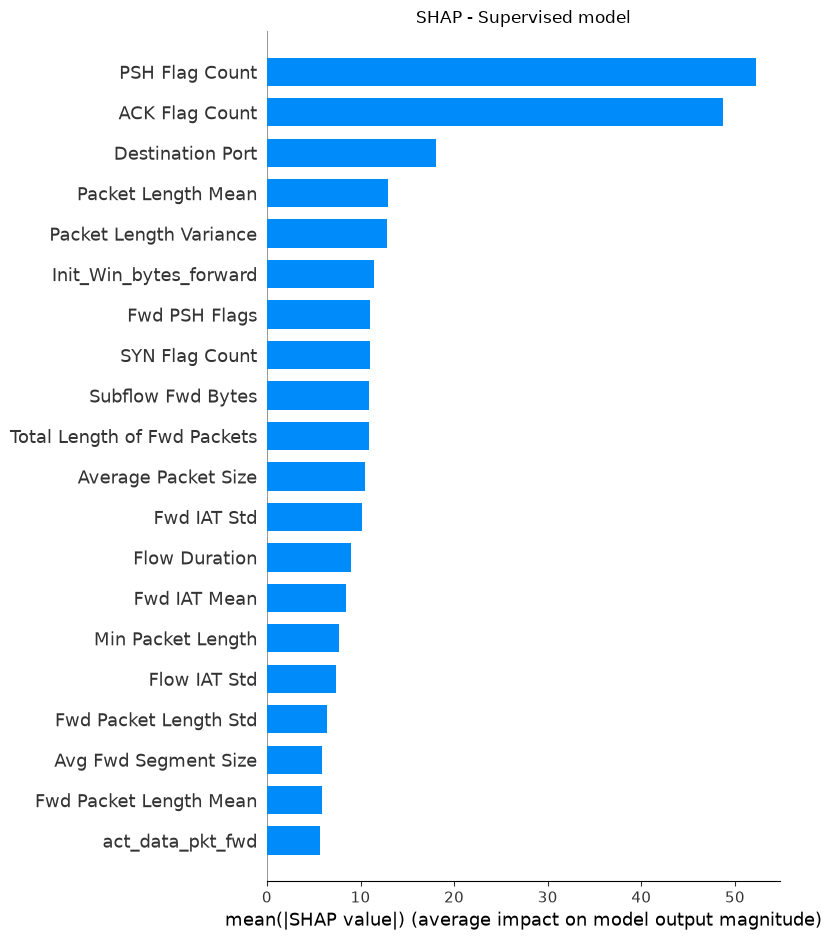

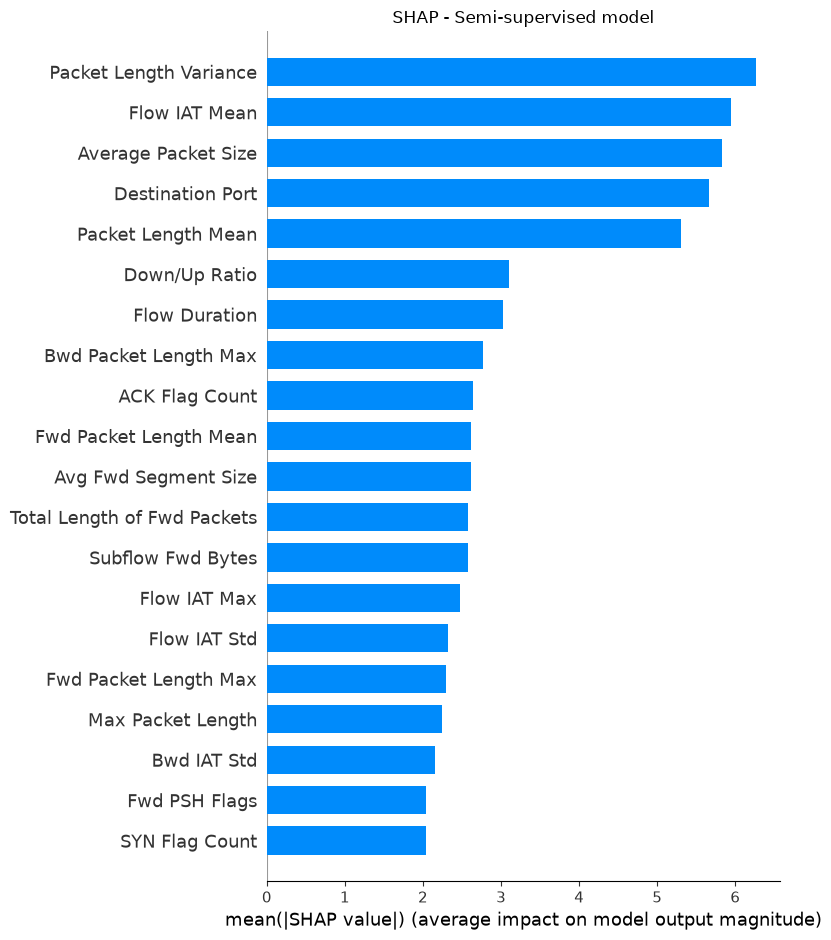

In [6]:
# Step 2: Generate SHAP explanations for both models

# A reproducible sample of 150 test observations is selected
# for model explanation.

# SHAP values estimate how strongly each feature contributes
# to the model's predictions.

# Summary plots show the average absolute SHAP importance
# of the features for each model.
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(X_test_scaled), size=150, replace=False)
X_explain_sample = X_test_scaled[sample_idx]

explainer_sup = shap.Explainer(lr_full, X_train_scaled[:100], feature_names=feature_names)
shap_values_sup = explainer_sup(X_explain_sample)

explainer_semi = shap.Explainer(pl_5, X_train_scaled[:100], feature_names=feature_names)
shap_values_semi = explainer_semi(X_explain_sample)

shap.summary_plot(shap_values_sup, X_explain_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP - Supervised model")
plt.tight_layout()
plt.savefig("shap_supervised.png", dpi=150)
plt.show()

shap.summary_plot(shap_values_semi, X_explain_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP - Semi-supervised model")
plt.tight_layout()
plt.savefig("shap_semi.png", dpi=150)
plt.show()


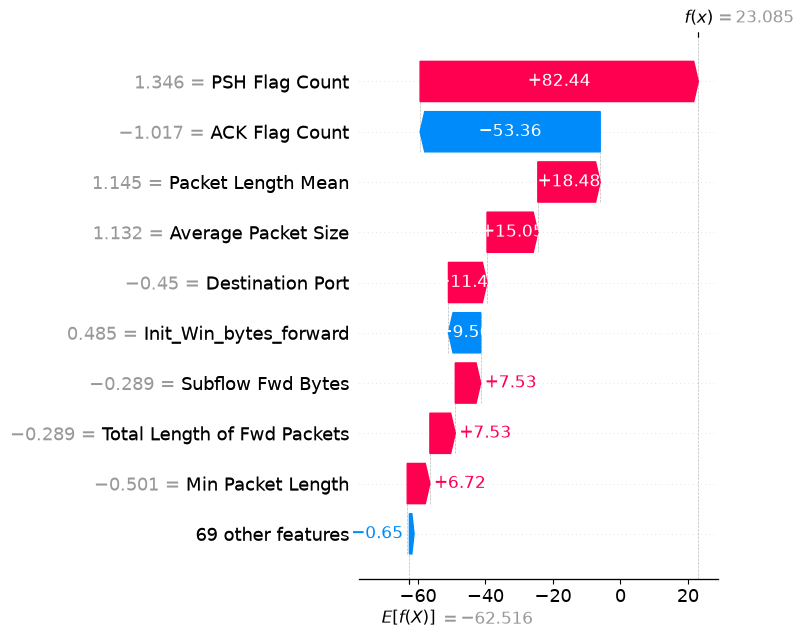

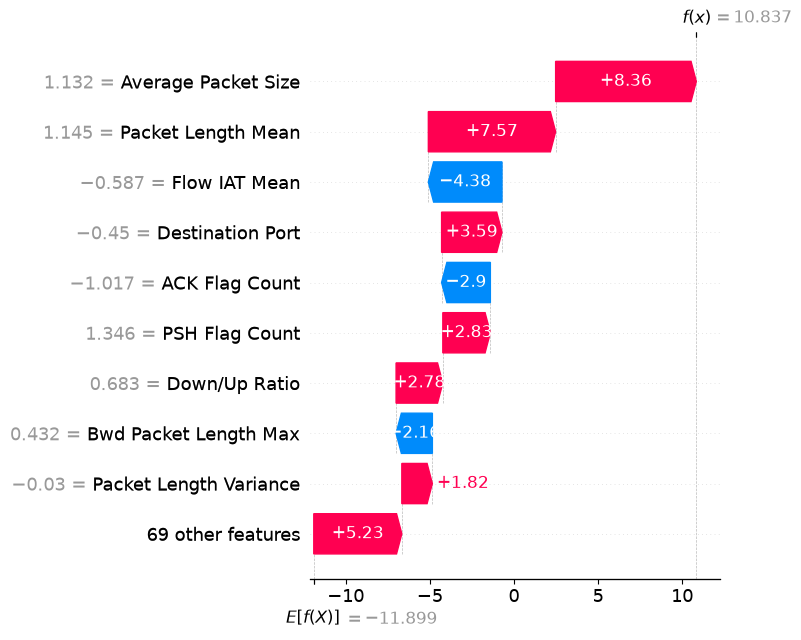

In [7]:
# Step 2: Generate SHAP waterfall plots

# Waterfall plots explain the contribution of individual features
# to a single prediction for each model.

shap.plots.waterfall(shap_values_sup[0], show=False)
plt.tight_layout()
plt.savefig("shap_supervised_waterfall.png", dpi=150)
plt.show()

shap.plots.waterfall(shap_values_semi[0], show=False)
plt.tight_layout()
plt.savefig("shap_semi_waterfall.png", dpi=150)
plt.show()

In [8]:

#Step 3: Generate LIME explanations for both models

# LIME creates a local explanation by approximating the model
# around an individual test observation.

# The five most influential features for the selected observation
# are displayed for each model.

lime_explainer = LimeTabularExplainer(
    X_train_scaled, feature_names=feature_names,
    class_names=["Normal", "Attack"], mode="classification", random_state=SEED)

print("LIME - Supervised model, sample 0:")
exp = lime_explainer.explain_instance(X_test_scaled[0], lr_full.predict_proba, num_features=5)
print(exp.as_list())

print("\nLIME - Semi-supervised model, sample 0:")
exp2 = lime_explainer.explain_instance(X_test_scaled[0], pl_5.predict_proba, num_features=5)
print(exp2.as_list())

LIME - Supervised model, sample 0:
[('PSH Flag Count <= -0.74', -0.2582083085023166), ('-1.02 < ACK Flag Count <= 0.98', 0.16782902769162322), ('Subflow Fwd Bytes > -0.28', -0.14513308183749665), ('Total Length of Fwd Packets > -0.28', -0.14013377575064656), ('Destination Port > -0.45', -0.1175980972398542)]

LIME - Semi-supervised model, sample 0:
[('Packet Length Variance > 0.42', 0.14744143423940945), ('Subflow Bwd Packets > 0.02', -0.14240862207230628), ('Bwd Header Length > 0.03', -0.1141599265385219), ('Total Backward Packets > 0.02', -0.10620979583357429), ('Destination Port > -0.45', -0.10113584378752578)]


In [9]:
#Step 3/4: Check LIME explanation stability

# The same test observation is explained twice using LIME.
# Comparing the two explanations helps assess how consistent
# the local explanation is for the same prediction.

run1 = lime_explainer.explain_instance(X_test_scaled[0], lr_full.predict_proba, num_features=5)
run2 = lime_explainer.explain_instance(X_test_scaled[0], lr_full.predict_proba, num_features=5)

print("LIME run 1:", run1.as_list())
print("LIME run 2:", run2.as_list())
print("\nIf these two lists look different, LIME is a bit unstable for this sample.")

LIME run 1: [('PSH Flag Count <= -0.74', -0.23746508886023338), ('Total Length of Fwd Packets > -0.28', -0.16339183471008925), ('Packet Length Variance > 0.42', 0.1322021495300104), ('-1.02 < ACK Flag Count <= 0.98', 0.12954625321891639), ('Destination Port > -0.45', -0.1283354757809845)]
LIME run 2: [('PSH Flag Count <= -0.74', -0.23663523302494754), ('Total Length of Fwd Packets > -0.28', -0.16444685600981146), ('Subflow Fwd Bytes > -0.28', -0.155214635583287), ('-1.02 < ACK Flag Count <= 0.98', 0.1390196958047675), ('Packet Length Variance > 0.42', 0.13304132963521922)]

If these two lists look different, LIME is a bit unstable for this sample.


In [10]:
# Step 5: Identify the two most important features for each model

# Mean absolute SHAP values are calculated across the explanation
# sample and used to rank features by their overall importance.

# The two features with the highest mean absolute SHAP values
# are selected for each model.

importance_sup = pd.Series(
    np.abs(shap_values_sup.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

importance_semi = pd.Series(
    np.abs(shap_values_semi.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

top2_sup = importance_sup.index[:2].tolist()
top2_semi = importance_semi.index[:2].tolist()

print("Top-2 features (supervised):     ", top2_sup)
print("Top-2 features (semi-supervised):", top2_semi)

Top-2 features (supervised):      ['PSH Flag Count', 'ACK Flag Count']
Top-2 features (semi-supervised): ['Packet Length Variance', 'Flow IAT Mean']


In [11]:
# Step 6.1: Levels for a feature (Low, Medium, High)

# A belief rule talks about levels, not raw numbers. We give each feature three
# reference values taken from the training data quantiles:
#   Low = 10th percentile, Medium = median, High = 90th percentile.
# For a 0/1 feature (like a flag count) the quantiles collapse, so we fall back
# to min / mean / max instead. We use the UNSCALED values so the rules are readable.

def make_levels(values):
    low = values.quantile(0.10)
    medium = values.quantile(0.50)
    high = values.quantile(0.90)
    if low == medium or medium == high:
        low = values.min()
        medium = values.mean()
        high = values.max()
    return [low, medium, high]

LEVEL_NAMES = ["Low", "Medium", "High"]

for feature in top2_sup + top2_semi:
    levels = make_levels(X_train[feature])
    print(feature, "->", "Low =", round(levels[0], 2), " Medium =", round(levels[1], 2), " High =", round(levels[2], 2))

PSH Flag Count -> Low = 0  Medium = 0.36  High = 1
ACK Flag Count -> Low = 0  Medium = 0.51  High = 1
Packet Length Variance -> Low = 0.0  Medium = 57918.29  High = 9554872.27
Flow IAT Mean -> Low = 209.0  Medium = 231879.67  High = 6093675.12


In [12]:
# Step 6.2: Beliefs from the data

# For each rule we look at the training rows that belong to it and count the share
# of attacks (p). The share is turned into a belief over {Low, Medium, High} risk:
#   p = 0   -> all belief on Low risk
#   p = 0.5 -> all belief on Medium risk
#   p = 1   -> all belief on High risk
# and values in between are shared between the two nearest levels.
#
# We never let a rule be more than 90% sure, and a rule built on fewer than 100 rows
# is trusted even less. Whatever is left over is ignorance: the rule saying "I do not
# fully know". A rule with no rows at all is pure ignorance (0, 0, 0).

def beliefs_from_attack_share(p, n_rows):
    if n_rows == 0:
        return 0.0, 0.0, 0.0

    high = max(0.0, (p - 0.5) / 0.5)
    low = max(0.0, (0.5 - p) / 0.5)
    medium = 1.0 - high - low

    support = 0.9 * min(1.0, n_rows / 100)
    return low * support, medium * support, high * support

print("Attack share 0.00 ->", np.round(beliefs_from_attack_share(0.00, 1000), 3))
print("Attack share 0.25 ->", np.round(beliefs_from_attack_share(0.25, 1000), 3))
print("Attack share 0.50 ->", np.round(beliefs_from_attack_share(0.50, 1000), 3))
print("Attack share 0.90 ->", np.round(beliefs_from_attack_share(0.90, 1000), 3))
print("Attack share 0.90 on only 20 rows ->", np.round(beliefs_from_attack_share(0.90, 20), 3))

Attack share 0.00 -> [0.9 0.  0. ]
Attack share 0.25 -> [0.45 0.45 0.  ]
Attack share 0.50 -> [0.  0.9 0. ]
Attack share 0.90 -> [0.   0.18 0.72]
Attack share 0.90 on only 20 rows -> [0.    0.036 0.144]


In [13]:
# Step 6.3: Build the belief rule base for two features

# One rule for every combination of levels: 3 levels x 3 levels = 9 rules.
# Each rule has: the two levels, the beliefs (beta) over Low / Medium / High risk,
# the ignorance, a rule weight theta and attribute weights delta.
# We start with theta = 1 and delta = (1, 1) for every rule (all rules and both
# features count equally). Step 7 uses these numbers.

def build_rule_base(feature_a, feature_b, X_data, y_data):
    levels_a = make_levels(X_data[feature_a])
    levels_b = make_levels(X_data[feature_b])

    # Put every training row in the level whose reference value is closest
    nearest_a = np.abs(X_data[feature_a].values[:, None] - np.array(levels_a)[None, :]).argmin(axis=1)
    nearest_b = np.abs(X_data[feature_b].values[:, None] - np.array(levels_b)[None, :]).argmin(axis=1)
    y_array = np.array(y_data)

    rules = []
    rule_number = 1
    for i in range(3):
        for j in range(3):
            in_rule = (nearest_a == i) & (nearest_b == j)
            n_rows = in_rule.sum()
            attack_share = y_array[in_rule].mean() if n_rows > 0 else np.nan

            low, medium, high = beliefs_from_attack_share(attack_share, n_rows)

            rules.append({
                "Rule": rule_number,
                feature_a: LEVEL_NAMES[i],
                feature_b: LEVEL_NAMES[j],
                "Rows": int(n_rows),
                "Attack share": round(attack_share, 3) if n_rows > 0 else np.nan,
                "Low": round(low, 3),
                "Medium": round(medium, 3),
                "High": round(high, 3),
                "Ignorance": round(1 - low - medium - high, 3),
                "theta": 1.0,
                "delta_a": 1.0,
                "delta_b": 1.0,
            })
            rule_number += 1

    return pd.DataFrame(rules), levels_a, levels_b

print("Function ready")

Function ready


In [14]:
# Step 6.4: The two rule bases (Step 6 DONE)

print("Belief rule base for the SUPERVISED model, features:", top2_sup)
rules_sup, levels_sup_a, levels_sup_b = build_rule_base(top2_sup[0], top2_sup[1], X_train, y_train)
display(rules_sup)

print("Belief rule base for the SEMI-SUPERVISED model, features:", top2_semi)
rules_semi, levels_semi_a, levels_semi_b = build_rule_base(top2_semi[0], top2_semi[1], X_train, y_train)
display(rules_semi)

# One rule written out in words, as in the instructions
def rule_in_words(rules, feature_a, feature_b, rule_number):
    r = rules[rules["Rule"] == rule_number].iloc[0]
    return ("IF " + feature_a + " is " + r[feature_a].upper() + " AND " + feature_b + " is " + r[feature_b].upper()
            + " THEN attack risk { High " + str(r["High"]) + ", Medium " + str(r["Medium"]) + ", Low " + str(r["Low"])
            + " } (ignorance " + str(r["Ignorance"]) + "), theta = " + str(r["theta"]) + ", delta = (1, 1)")

print()
print(rule_in_words(rules_sup, top2_sup[0], top2_sup[1], 1))
print(rule_in_words(rules_sup, top2_sup[0], top2_sup[1], 3))
print(rule_in_words(rules_semi, top2_semi[0], top2_semi[1], 9))

# The Medium rules for the flag features have no rows: a flag is 0 or 1, never in between.
# Those rules are pure ignorance, which is the honest answer.

Belief rule base for the SUPERVISED model, features: ['PSH Flag Count', 'ACK Flag Count']


,Rule,PSH Flag Count,ACK Flag Count,Rows,Attack share,Low,Medium,High,Ignorance,theta,delta_a,delta_b
0,1,Low,Low,18623,0.000,0.900,0.000,0.000,0.1,1.0,1.0,1.0
1,2,Low,Medium,0,NaN,0.000,0.000,0.000,1.0,1.0,1.0,1.0
2,3,Low,High,67629,0.620,0.000,0.685,0.215,0.1,1.0,1.0,1.0
3,4,Medium,Low,0,NaN,0.000,0.000,0.000,1.0,1.0,1.0,1.0
4,5,Medium,Medium,0,NaN,0.000,0.000,0.000,1.0,1.0,1.0,1.0
5,6,Medium,High,0,NaN,0.000,0.000,0.000,1.0,1.0,1.0,1.0
6,7,High,Low,47147,0.739,0.000,0.471,0.429,0.1,1.0,1.0,1.0
7,8,High,Medium,0,NaN,0.000,0.000,0.000,1.0,1.0,1.0,1.0
8,9,High,High,450,0.191,0.556,0.344,0.000,0.1,1.0,1.0,1.0


Belief rule base for the SEMI-SUPERVISED model, features: ['Packet Length Variance', 'Flow IAT Mean']


,Rule,Packet Length Variance,Flow IAT Mean,Rows,Attack share,Low,Medium,High,Ignorance,theta,delta_a,delta_b
0,1,Low,Low,27203,0.048,0.814,0.086,0.000,0.1,1.0,1.0,1.0
1,2,Low,Medium,34713,0.679,0.000,0.578,0.322,0.1,1.0,1.0,1.0
2,3,Low,High,4384,0.680,0.000,0.576,0.324,0.1,1.0,1.0,1.0
3,4,Medium,Low,13485,0.711,0.000,0.521,0.379,0.1,1.0,1.0,1.0
4,5,Medium,Medium,12180,0.449,0.091,0.809,0.000,0.1,1.0,1.0,1.0
5,6,Medium,High,12324,0.652,0.000,0.626,0.274,0.1,1.0,1.0,1.0
6,7,High,Low,13220,0.909,0.000,0.163,0.737,0.1,1.0,1.0,1.0
7,8,High,Medium,9772,0.912,0.000,0.159,0.741,0.1,1.0,1.0,1.0
8,9,High,High,6568,0.751,0.000,0.448,0.452,0.1,1.0,1.0,1.0



IF PSH Flag Count is LOW AND ACK Flag Count is LOW THEN attack risk { High 0.0, Medium 0.0, Low 0.9 } (ignorance 0.1), theta = 1.0, delta = (1, 1)
IF PSH Flag Count is LOW AND ACK Flag Count is HIGH THEN attack risk { High 0.215, Medium 0.685, Low 0.0 } (ignorance 0.1), theta = 1.0, delta = (1, 1)
IF Packet Length Variance is HIGH AND Flow IAT Mean is HIGH THEN attack risk { High 0.452, Medium 0.448, Low 0.0 } (ignorance 0.1), theta = 1.0, delta = (1, 1)


In [15]:
# Step 7.1: Input transformation

# A crisp value is turned into matching degrees over the three levels.
# A value exactly on a reference value matches that level fully (1).
# A value between two reference values is shared between them, for example
# a value halfway between Medium and High counts 0.5 Medium and 0.5 High.
# Below Low counts fully as Low, above High counts fully as High.
# A missing value (NaN) gives None, Step 7.3 handles that.

def input_transformation(value, levels):
    low, medium, high = levels

    if np.isnan(value):
        return None
    if value <= low:
        return np.array([1.0, 0.0, 0.0])
    if value >= high:
        return np.array([0.0, 0.0, 1.0])
    if value <= medium:
        part_low = (medium - value) / (medium - low)
        return np.array([part_low, 1.0 - part_low, 0.0])
    part_medium = (high - value) / (high - medium)
    return np.array([0.0, part_medium, 1.0 - part_medium])

# Small check with the levels of the first semi-supervised feature
levels_demo = levels_semi_a
value_demo = (levels_demo[1] + levels_demo[2]) / 2   # halfway between Medium and High
print(top2_semi[0], "levels:", np.round(levels_demo, 2))
print("value", round(value_demo, 2), "-> matching degrees (Low, Medium, High):", input_transformation(value_demo, levels_demo))
print("value", round(levels_demo[0], 2), "-> matching degrees (Low, Medium, High):", input_transformation(levels_demo[0], levels_demo))
print("missing value -> ", input_transformation(np.nan, levels_demo))

Packet Length Variance levels: [      0.     57918.29 9554872.27]
value 4806395.28 -> matching degrees (Low, Medium, High): [0.  0.5 0.5]
value 0.0 -> matching degrees (Low, Medium, High): [1. 0. 0.]
missing value ->  None


In [16]:
# Step 7.2: Rule activation weights

# How strongly does each rule match the input? A rule "A is HIGH and B is LOW" matches
# by (degree of A being High) x (degree of B being Low). The attribute weights delta
# are used as exponents (after dividing by the largest delta), so a feature with a
# small delta matters less. The rule weight theta scales the result.
# At the end we normalise so all activation weights sum to 1.
# A missing feature does not take part: its factor is 1 for every rule.

def activation_weights(match_a, match_b, rules, feature_a, feature_b):
    weights = np.zeros(len(rules))

    for k in range(len(rules)):
        rule = rules.iloc[k]
        delta_max = max(rule["delta_a"], rule["delta_b"])

        matching = 1.0
        if match_a is not None:
            level_a = LEVEL_NAMES.index(rule[feature_a])
            matching = matching * match_a[level_a] ** (rule["delta_a"] / delta_max)
        if match_b is not None:
            level_b = LEVEL_NAMES.index(rule[feature_b])
            matching = matching * match_b[level_b] ** (rule["delta_b"] / delta_max)

        weights[k] = rule["theta"] * matching

    if weights.sum() > 0:
        weights = weights / weights.sum()
    return weights

print("Function ready")

Function ready


In [17]:
# Step 7.3: Belief update for missing features

# If a feature is missing for a sample, every rule knows less than it normally would.
# We shrink the rule's beliefs by the share of attribute weight that is still available:
# with two features of equal weight and one missing, the beliefs are halved.
# The part we removed is not hidden, it becomes ignorance.

def belief_update(rules, a_missing, b_missing):
    beliefs = rules[["Low", "Medium", "High"]].values.astype(float).copy()

    for k in range(len(rules)):
        total = rules.iloc[k]["delta_a"] + rules.iloc[k]["delta_b"]
        available = total
        if a_missing:
            available = available - rules.iloc[k]["delta_a"]
        if b_missing:
            available = available - rules.iloc[k]["delta_b"]
        beliefs[k] = beliefs[k] * available / total

    return beliefs

print("Rule 9 beliefs, both features present:", belief_update(rules_semi, False, False)[8].round(3))
print("Rule 9 beliefs, one feature missing:  ", belief_update(rules_semi, True, False)[8].round(3), " (the rest is ignorance)")

Rule 9 beliefs, both features present: [0.    0.448 0.452]
Rule 9 beliefs, one feature missing:   [0.    0.224 0.226]  (the rest is ignorance)


In [18]:
# Step 7.4: Rule aggregation with the Evidential Reasoning (ER) approach

# The active rules are combined into one belief distribution over {Low, Medium, High}
# plus a remaining ignorance. The analytical ER formula works like this:
#   m[k, n]   = w[k] * beta[k, n]            belief the rule gives to level n
#   m_bar[k]  = 1 - w[k]                     part of the rule that is not activated
#   m_tilde[k] = w[k] * (1 - sum of beta[k]) ignorance the rule admits
# and the products over all rules give the combined result.

def evidential_reasoning(weights, beliefs):
    n_levels = beliefs.shape[1]

    m = weights[:, None] * beliefs
    m_bar = 1.0 - weights
    m_tilde = weights * (1.0 - beliefs.sum(axis=1))

    product_level = np.prod(m + (m_bar + m_tilde)[:, None], axis=0)   # one number per level
    product_H = np.prod(m_bar + m_tilde)
    product_bar = np.prod(m_bar)

    denominator = product_level.sum() - (n_levels - 1) * product_H - product_bar
    if denominator == 0:          # no rule was activated at all
        return np.zeros(n_levels), 1.0

    combined_beliefs = (product_level - product_H) / denominator
    combined_ignorance = (product_H - product_bar) / denominator
    return combined_beliefs, combined_ignorance

# Check: one rule fully active should just return that rule's own beliefs
w_check = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1.0])
b_check = rules_semi[["Low", "Medium", "High"]].values.astype(float)
print("Rule 9 alone ->", np.round(evidential_reasoning(w_check, b_check)[0], 3), " ignorance", round(evidential_reasoning(w_check, b_check)[1], 3))
print("Rule 9 in the table:", b_check[8].round(3))

Rule 9 alone -> [0.    0.448 0.452]  ignorance 0.1
Rule 9 in the table: [0.    0.448 0.452]


In [19]:
# Step 7.5: Decision, and the whole system in one function

# The belief is turned into a utility score: Low = 0, Medium = 50, High = 100.
# What the system does not know (ignorance) is treated as neutral, 50.
# A sample is labelled Attack when the score passes a threshold (chosen in Step 7.6).

UTILITY = np.array([0.0, 50.0, 100.0])

def utility_score(beliefs, ignorance):
    return float((UTILITY * beliefs).sum() + 50.0 * ignorance)

# One sample through all five steps. Returns the combined belief, the ignorance and the score.
def brbes_one_sample(value_a, value_b, rules, levels_a, levels_b, feature_a, feature_b, show=False):
    match_a = input_transformation(value_a, levels_a)                        # step 2 of the framework
    match_b = input_transformation(value_b, levels_b)
    weights = activation_weights(match_a, match_b, rules, feature_a, feature_b)   # step 3
    beliefs = belief_update(rules, match_a is None, match_b is None)          # step 4
    combined, ignorance = evidential_reasoning(weights, beliefs)              # step 5
    score = utility_score(combined, ignorance)

    if show:
        print("  Input:", feature_a, "=", value_a, "|", feature_b, "=", value_b)
        print("  Matching degrees:", feature_a, "->", None if match_a is None else match_a.round(3),
              "|", feature_b, "->", None if match_b is None else match_b.round(3))
        active = np.where(weights > 0)[0]
        print("  Active rules:", [(int(rules.iloc[k]["Rule"]), round(float(weights[k]), 3)) for k in active])
        print("  Combined belief (Low, Medium, High):", combined.round(3), " ignorance:", round(ignorance, 3))
        print("  Utility score:", round(score, 1))
    return combined, ignorance, score

# Walk one attack and one normal validation sample through the semi-supervised BRBES
first_attack = X_val.index[y_val.values == 1][0]
first_normal = X_val.index[y_val.values == 0][0]

print("Attack sample from the validation set:")
brbes_one_sample(X_val.loc[first_attack, top2_semi[0]], X_val.loc[first_attack, top2_semi[1]],
                 rules_semi, levels_semi_a, levels_semi_b, top2_semi[0], top2_semi[1], show=True)
print()
print("Normal sample from the validation set:")
brbes_one_sample(X_val.loc[first_normal, top2_semi[0]], X_val.loc[first_normal, top2_semi[1]],
                 rules_semi, levels_semi_a, levels_semi_b, top2_semi[0], top2_semi[1], show=True)
print()
print("Same attack sample, but the second feature is missing:")
result_missing = brbes_one_sample(X_val.loc[first_attack, top2_semi[0]], np.nan,
                 rules_semi, levels_semi_a, levels_semi_b, top2_semi[0], top2_semi[1], show=True)

Attack sample from the validation set:
  Input: Packet Length Variance = 6523729.278 | Flow IAT Mean = 179167.2857
  Matching degrees: Packet Length Variance -> [0.    0.319 0.681] | Flow IAT Mean -> [0.228 0.772 0.   ]
  Active rules: [(4, 0.073), (5, 0.247), (7, 0.155), (8, 0.526)]
  Combined belief (Low, Medium, High): [0.016 0.316 0.582]  ignorance: 0.085
  Utility score: 78.3

Normal sample from the validation set:
  Input: Packet Length Variance = 176645.9058 | Flow IAT Mean = 18866.86364
  Matching degrees: Packet Length Variance -> [0.    0.987 0.013] | Flow IAT Mean -> [0.919 0.081 0.   ]
  Active rules: [(4, 0.908), (5, 0.08), (7, 0.011), (8, 0.001)]
  Combined belief (Low, Medium, High): [0.001 0.54  0.363]  ignorance: 0.095
  Utility score: 68.1

Same attack sample, but the second feature is missing:
  Input: Packet Length Variance = 6523729.278 | Flow IAT Mean = nan
  Matching degrees: Packet Length Variance -> [0.    0.319 0.681] | Flow IAT Mean -> None
  Active rules: [(

In [20]:
# Step 7.6: Run the BRBES on a whole data set and choose the threshold (Step 7 DONE)

# We score every row and pick the threshold that gives the best macro-F1 on the
# VALIDATION set. The test set is still untouched, it is used in Step 8.

def brbes_scores(X_data, rules, levels_a, levels_b, feature_a, feature_b):
    values_a = X_data[feature_a].values
    values_b = X_data[feature_b].values
    scores = np.zeros(len(X_data))
    for i in range(len(X_data)):
        combined, ignorance, score = brbes_one_sample(values_a[i], values_b[i], rules, levels_a, levels_b, feature_a, feature_b)
        scores[i] = score
    return scores

def choose_threshold(scores, y_true):
    best_threshold = 50
    best_f1 = 0
    for threshold in range(20, 85, 5):
        pred = (scores >= threshold).astype(int)
        f1 = f1_score(y_true, pred, average="macro")
        print("  threshold", threshold, "-> macro-F1", round(f1, 4))
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    return best_threshold

print("Supervised BRBES on the validation set:")
val_scores_sup = brbes_scores(X_val, rules_sup, levels_sup_a, levels_sup_b, top2_sup[0], top2_sup[1])
threshold_sup = choose_threshold(val_scores_sup, y_val)
print("  chosen threshold:", threshold_sup)

print("Semi-supervised BRBES on the validation set:")
val_scores_semi = brbes_scores(X_val, rules_semi, levels_semi_a, levels_semi_b, top2_semi[0], top2_semi[1])
threshold_semi = choose_threshold(val_scores_semi, y_val)
print("  chosen threshold:", threshold_semi)

Supervised BRBES on the validation set:
  threshold 20 -> macro-F1 0.6501
  threshold 25 -> macro-F1 0.6539
  threshold 30 -> macro-F1 0.6539
  threshold 35 -> macro-F1 0.6539
  threshold 40 -> macro-F1 0.6539
  threshold 45 -> macro-F1 0.6539
  threshold 50 -> macro-F1 0.6539
  threshold 55 -> macro-F1 0.6539
  threshold 60 -> macro-F1 0.6539
  threshold 65 -> macro-F1 0.5929
  threshold 70 -> macro-F1 0.5929
  threshold 75 -> macro-F1 0.2988
  threshold 80 -> macro-F1 0.2988
  chosen threshold: 25
Semi-supervised BRBES on the validation set:
  threshold 20 -> macro-F1 0.7081
  threshold 25 -> macro-F1 0.7147
  threshold 30 -> macro-F1 0.719
  threshold 35 -> macro-F1 0.7218
  threshold 40 -> macro-F1 0.7245
  threshold 45 -> macro-F1 0.7264
  threshold 50 -> macro-F1 0.7715
  threshold 55 -> macro-F1 0.7837
  threshold 60 -> macro-F1 0.7865
  threshold 65 -> macro-F1 0.7907
  threshold 70 -> macro-F1 0.6258
  threshold 75 -> macro-F1 0.5679
  threshold 80 -> macro-F1 0.5176
  chosen 

In [21]:
# Step 8.1: Score everything on the TEST SET (first time we touch it)

# Same five metrics as in Lab 1 and Lab 2. A BRBES has no predict_proba, so for
# ROC-AUC we use its utility score divided by 100 as the "attack probability".

def evaluate_predictions(pred, score, y_true, name):
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, pred), 5),
        "Macro-F1": round(f1_score(y_true, pred, average="macro"), 5),
        "Recall": round(recall_score(y_true, pred), 5),
        "ROC-AUC": round(roc_auc_score(y_true, score), 5),
        "FAR": round(fp / (fp + tn), 5)
    }

results_lab3 = []

# The two black boxes
results_lab3.append(evaluate_predictions(lr_full.predict(X_test_scaled), lr_full.predict_proba(X_test_scaled)[:, 1],
                                         y_test, "Supervised black box (Lab 1 LR)"))
results_lab3.append(evaluate_predictions(pl_5.predict(X_test_scaled), pl_5.predict_proba(X_test_scaled)[:, 1],
                                         y_test, "Semi-supervised black box (Lab 2 pseudo-label)"))

# The two BRBES, with the thresholds chosen on the validation set in Step 7.6
print("Scoring the supervised BRBES on the test set ...")
test_scores_sup = brbes_scores(X_test, rules_sup, levels_sup_a, levels_sup_b, top2_sup[0], top2_sup[1])
pred_brbes_sup = (test_scores_sup >= threshold_sup).astype(int)
results_lab3.append(evaluate_predictions(pred_brbes_sup, test_scores_sup / 100, y_test,
                                         "Supervised BRBES (" + top2_sup[0] + ", " + top2_sup[1] + ")"))

print("Scoring the semi-supervised BRBES on the test set ...")
test_scores_semi = brbes_scores(X_test, rules_semi, levels_semi_a, levels_semi_b, top2_semi[0], top2_semi[1])
pred_brbes_semi = (test_scores_semi >= threshold_semi).astype(int)
results_lab3.append(evaluate_predictions(pred_brbes_semi, test_scores_semi / 100, y_test,
                                         "Semi-supervised BRBES (" + top2_semi[0] + ", " + top2_semi[1] + ")"))

results_table = pd.DataFrame(results_lab3)
display(results_table)

Scoring the supervised BRBES on the test set ...
Scoring the semi-supervised BRBES on the test set ...


,Model,Accuracy,Macro-F1,Recall,ROC-AUC,FAR
0,Supervised black box (Lab 1 LR),0.99901,0.99899,0.99902,0.99995,0.00100
1,Semi-supervised black box (Lab 2 pseudo-label),0.99776,0.99771,0.99871,0.99878,0.00352
2,"Supervised BRBES (PSH Flag Count, ACK Flag Count)",0.71856,0.65577,0.99824,0.71144,0.65804
3,"Semi-supervised BRBES (Packet Length Variance,...",0.80306,0.79247,0.89654,0.83509,0.32281


Direction 1: BRBES vs its own black box
  Supervised:      macro-F1 0.99899 -> 0.65577  (drop 0.3432 )  | recall 0.99902 -> 0.99824  | FAR 0.001 -> 0.65804
  Semi-supervised: macro-F1 0.99771 -> 0.79247  (drop 0.2052 )  | recall 0.99871 -> 0.89654  | FAR 0.00352 -> 0.32281

Direction 2: BRBES vs BRBES
  Supervised BRBES      macro-F1 0.65577  recall 0.99824  FAR 0.65804
  Semi-supervised BRBES macro-F1 0.79247  recall 0.89654  FAR 0.32281
  -> the semi-supervised rule base is the more accurate one


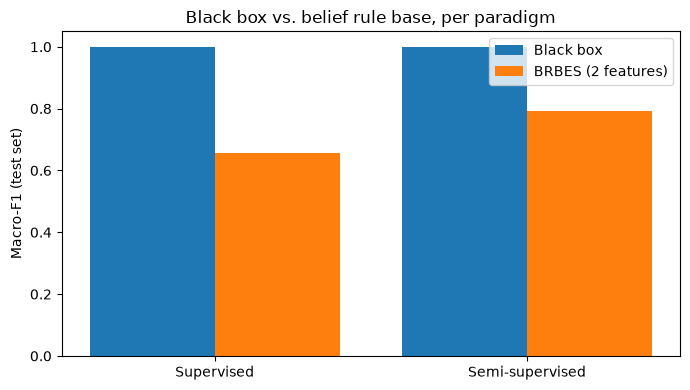

In [22]:
# Step 8.2: Compare in two directions

# Direction 1: each BRBES against its own black box (what did we lose for the transparency?)
# Direction 2: the two BRBES against each other (which paradigm gave the better rule base?)

black_sup, black_semi, brbes_sup, brbes_semi = results_lab3

print("Direction 1: BRBES vs its own black box")
print("  Supervised:      macro-F1", black_sup["Macro-F1"], "->", brbes_sup["Macro-F1"],
      " (drop", round(black_sup["Macro-F1"] - brbes_sup["Macro-F1"], 4), ")",
      " | recall", black_sup["Recall"], "->", brbes_sup["Recall"],
      " | FAR", black_sup["FAR"], "->", brbes_sup["FAR"])
print("  Semi-supervised: macro-F1", black_semi["Macro-F1"], "->", brbes_semi["Macro-F1"],
      " (drop", round(black_semi["Macro-F1"] - brbes_semi["Macro-F1"], 4), ")",
      " | recall", black_semi["Recall"], "->", brbes_semi["Recall"],
      " | FAR", black_semi["FAR"], "->", brbes_semi["FAR"])

print()
print("Direction 2: BRBES vs BRBES")
print("  Supervised BRBES      macro-F1", brbes_sup["Macro-F1"], " recall", brbes_sup["Recall"], " FAR", brbes_sup["FAR"])
print("  Semi-supervised BRBES macro-F1", brbes_semi["Macro-F1"], " recall", brbes_semi["Recall"], " FAR", brbes_semi["FAR"])
if brbes_semi["Macro-F1"] > brbes_sup["Macro-F1"]:
    print("  -> the semi-supervised rule base is the more accurate one")
else:
    print("  -> the supervised rule base is the more accurate one")

# Bar chart for the report
labels = ["Supervised", "Semi-supervised"]
x = np.arange(len(labels))
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, [black_sup["Macro-F1"], black_semi["Macro-F1"]], width=0.4, label="Black box")
plt.bar(x + 0.2, [brbes_sup["Macro-F1"], brbes_semi["Macro-F1"]], width=0.4, label="BRBES (2 features)")
plt.xticks(x, labels)
plt.ylabel("Macro-F1 (test set)")
plt.ylim(0, 1.05)
plt.title("Black box vs. belief rule base, per paradigm")
plt.legend()
plt.tight_layout()
plt.savefig("brbes_vs_blackbox.png", dpi=150)
plt.show()

In [23]:
# Step 8.3: Do the paradigms rely on the same features? (Step 8 DONE)

# The top features per paradigm, side by side, plus where each model ranks the other's picks.
print("Supervised model top 3:     ", importance_sup.index[:3].tolist())
print("Semi-supervised model top 3:", importance_semi.index[:3].tolist())
print()
for feature in top2_sup:
    print(feature, "-> rank", importance_sup.index.get_loc(feature) + 1, "in supervised,",
          "rank", importance_semi.index.get_loc(feature) + 1, "in semi-supervised")
for feature in top2_semi:
    print(feature, "-> rank", importance_sup.index.get_loc(feature) + 1, "in supervised,",
          "rank", importance_semi.index.get_loc(feature) + 1, "in semi-supervised")

# Extra check for the discussion: how much of the drop is just from using 2 features?
# A plain Logistic Regression on the same 2 features shows what a black box can do with them.
print()
for name, features in [("supervised", top2_sup), ("semi-supervised", top2_semi)]:
    cols = [feature_names.index(f) for f in features]
    lr_2 = LogisticRegression(C=100, max_iter=1000, random_state=SEED)
    lr_2.fit(X_train_scaled[:, cols], y_train)
    f1_2 = f1_score(y_test, lr_2.predict(X_test_scaled[:, cols]), average="macro")
    print("LR on only the", name, "top-2 features -> test macro-F1:", round(f1_2, 4))

Supervised model top 3:      ['PSH Flag Count', 'ACK Flag Count', 'Destination Port']
Semi-supervised model top 3: ['Packet Length Variance', 'Flow IAT Mean', 'Average Packet Size']

PSH Flag Count -> rank 1 in supervised, rank 25 in semi-supervised
ACK Flag Count -> rank 2 in supervised, rank 9 in semi-supervised
Packet Length Variance -> rank 5 in supervised, rank 1 in semi-supervised
Flow IAT Mean -> rank 27 in supervised, rank 2 in semi-supervised

LR on only the supervised top-2 features -> test macro-F1: 0.6524
LR on only the semi-supervised top-2 features -> test macro-F1: 0.7218
